In [8]:
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

print(" librerias instaladas con exito")

 librerias instaladas con exito


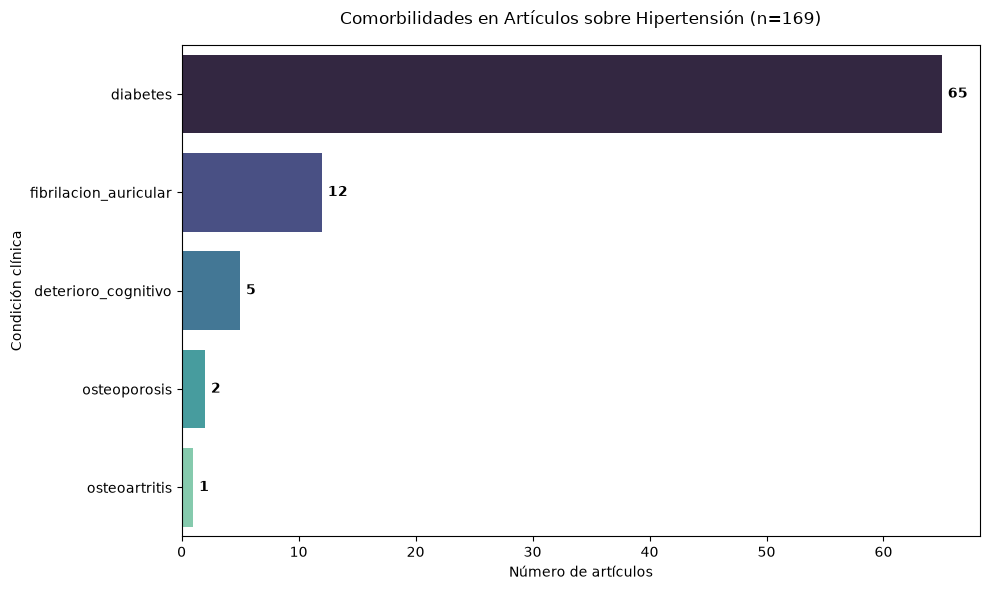

In [3]:
conn = sqlite3.connect("../cardioresearch.db")
df = pd.read_sql_query("SELECT pmid, title, abstract FROM articles", conn)
conn.close()

df['title'] = df['title'].fillna('')
df['abstract'] = df['abstract'].fillna('')
df['texto'] = (df['title'] + " " + df['abstract']).str.lower()

patrones = {
    "hipertension": r"\b(hypertension|blood pressure)\b",
    "deterioro_cognitivo": r"\b(cognitive impairment|dementia|mci)\b",
    "fibrilacion_auricular": r"\b(atrial fibrillation|afib)\b",
    "osteoartritis": r"\b(osteoarthritis)\b",
    "osteoporosis": r"\b(osteoporosis)\b",
    "diabetes": r"\b(diabetes|t2dm|mellitus)\b",
}
for cond, pat in patrones.items():
    df[cond] = df['texto'].apply(lambda x: 1 if re.search(pat, x) else 0)

df_hta = df[df['hipertension'] == 1]
comorbilidades = ["diabetes", "deterioro_cognitivo", "fibrilacion_auricular", "osteoartritis", "osteoporosis"]
frecuencias = df_hta[comorbilidades].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=frecuencias.values, y=frecuencias.index, hue=frecuencias.index, palette="mako", legend=False)
plt.title(f"Comorbilidades en Artículos sobre Hipertensión (n={len(df_hta)})", pad=15)
plt.xlabel("Número de artículos")
plt.ylabel("Condición clínica")
for i, v in enumerate(frecuencias.values):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
import os
print(os.getcwd())
print(os.path.exists('cardioresearch.db'))

/Users/anaisabecolinaarismendi/Documents/GitHub/CardioResearch/notebooks
False


In [5]:
import sqlite3
import pandas as pd
from pathlib import Path

# Ruta explícita al archivo, independiente de dónde se ejecute el notebook
db_path = Path("../cardioresearch.db")  # ajusta si tu .db está en otra carpeta
assert db_path.exists(), f"No se encontró la base de datos en: {db_path.resolve()}"

conn = sqlite3.connect(db_path)

# Verifica qué tablas existen realmente antes de consultar
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tablas)

# Carga de datos uniendo ambas tablas por su PMID
query = """
    SELECT a.*, c.clean_title, c.clean_abstract, c.combined_text
    FROM articles a
    LEFT JOIN clean_articles c ON a.pmid = c.pmid
"""
df = pd.read_sql(query, conn)
print(f"Total de registros: {df.shape[0]}, Columnas: {df.shape[1]}")

conn.close()

             name
0        articles
1  clean_articles
Total de registros: 200, Columnas: 7


count    200.000000
mean     250.980000
std       81.596197
min        0.000000
25%      209.000000
50%      248.000000
75%      282.250000
max      611.000000
Name: abstract_len, dtype: float64


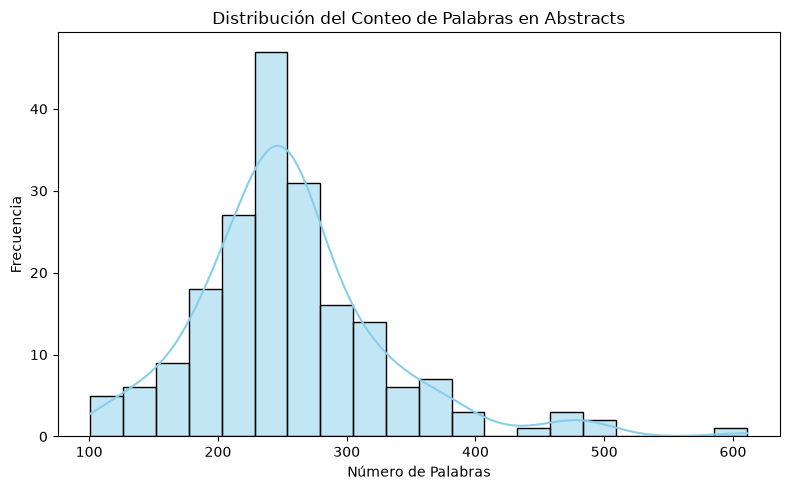

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la longitud de cada abstract en palabras (excluyendo nulos)
df['abstract_len'] = df['abstract'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

# Estadísticas básicas
print(df['abstract_len'].describe())

# Visualización
plt.figure(figsize=(8, 5))
sns.histplot(df.loc[df['abstract_len'] > 0, 'abstract_len'], bins=20, kde=True, color='skyblue')
plt.title('Distribución del Conteo de Palabras en Abstracts')
plt.xlabel('Número de Palabras')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

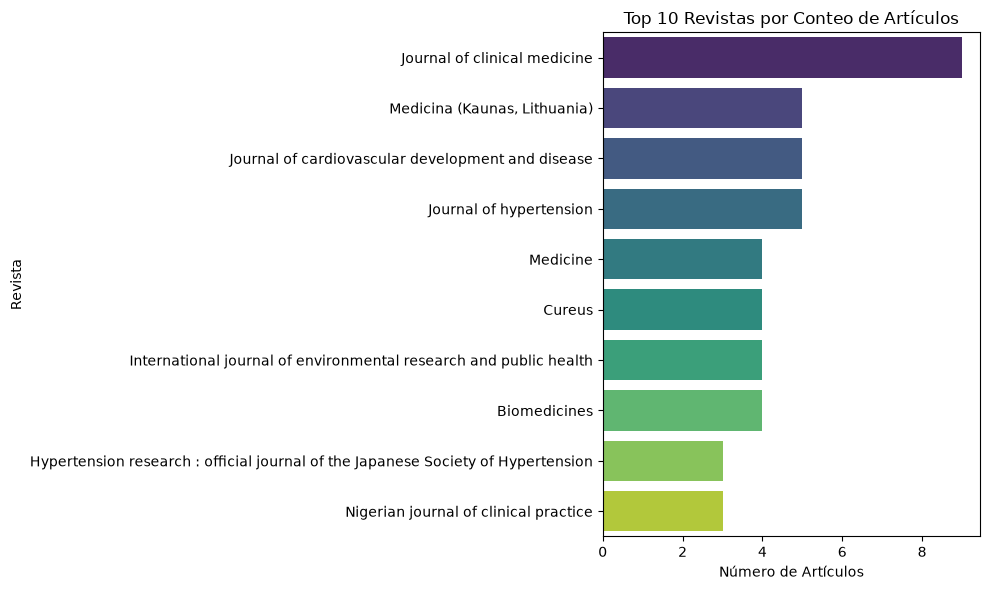

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener el Top 10 de revistas
top_journals = df['journal'].value_counts().head(10)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_journals.index,
    x=top_journals.values,
    hue=top_journals.index,
    palette='viridis',
    legend=False
)
plt.title('Top 10 Revistas por Conteo de Artículos')
plt.xlabel('Número de Artículos')
plt.ylabel('Revista')
plt.tight_layout()
plt.show()

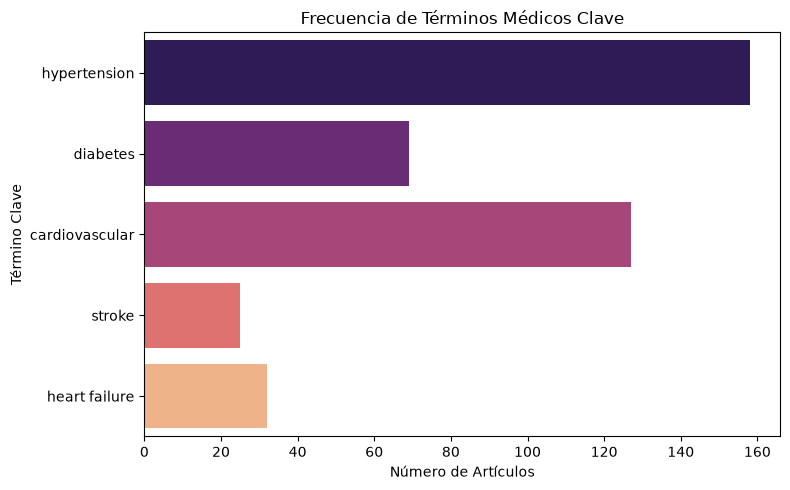

In [8]:
# Definición de términos médicos clave
keywords = ['hypertension', 'diabetes', 'cardiovascular', 'stroke', 'heart failure']

# Conteo de frecuencia en los abstracts
keyword_counts = {
    kw: df['abstract'].str.contains(kw, case=False, na=False, regex=False).sum()
    for kw in keywords
}

# Visualización
plt.figure(figsize=(8, 5))
sns.barplot(
    x=list(keyword_counts.values()),
    y=list(keyword_counts.keys()),
    hue=list(keyword_counts.keys()),
    palette='magma',
    legend=False
)
plt.title('Frecuencia de Términos Médicos Clave')
plt.xlabel('Número de Artículos')
plt.ylabel('Término Clave')
plt.tight_layout()
plt.show()

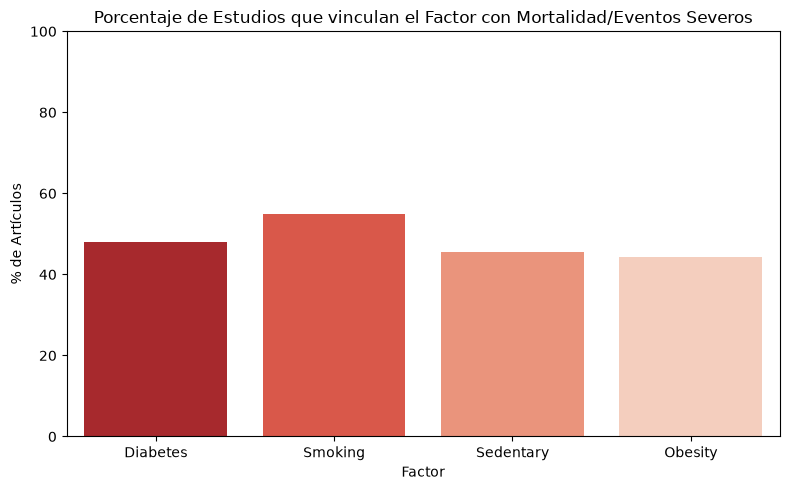

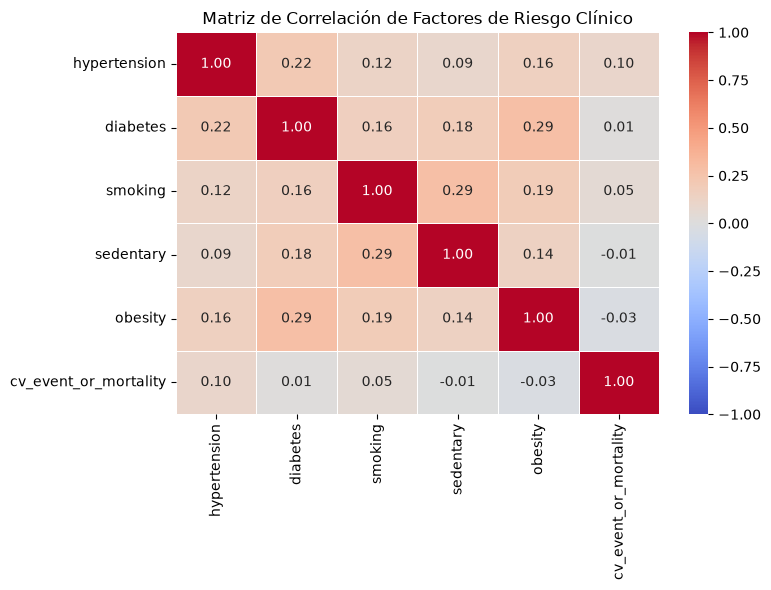

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Conexión y Extracción
db_path = Path("../cardioresearch.db")  # ajusta según tu estructura de carpetas
assert db_path.exists(), f"No se encontró la base de datos en: {db_path.resolve()}"
conn = sqlite3.connect(db_path)
query = "SELECT abstract FROM articles"
df = pd.read_sql(query, conn)
conn.close()

# 2. Ingeniería de Características (NLP Básico)
# Marcamos con 1 si el artículo menciona el factor de riesgo y 0 si no.
df['hypertension'] = df['abstract'].str.contains(r'hypertens', case=False, na=False).astype(int)
df['diabetes'] = df['abstract'].str.contains(r'diabet', case=False, na=False).astype(int)
df['smoking'] = df['abstract'].str.contains(r'smok|tobacco', case=False, na=False).astype(int)
df['sedentary'] = df['abstract'].str.contains(r'sedentary|inactiv|physical activity', case=False, na=False).astype(int)
df['obesity'] = df['abstract'].str.contains(r'obes|bmi|body mass', case=False, na=False).astype(int)

# Marcamos con 1 si el artículo menciona mortalidad o eventos cardiovasculares severos
df['cv_event_or_mortality'] = df['abstract'].str.contains(
    r'mortality|death|stroke|infarction|heart failure', case=False, na=False
).astype(int)

# 3. Gráfico de Riesgo (Frecuencia de eventos severos asociados a cada factor)
risk_factors = ['diabetes', 'smoking', 'sedentary', 'obesity']
outcome_rates = []
for factor in risk_factors:
    subset = df[df[factor] == 1]
    rate = subset['cv_event_or_mortality'].mean() * 100 if len(subset) > 0 else 0
    outcome_rates.append({'Factor': factor.capitalize(), 'Tasa_Mortalidad_Eventos': rate})

df_risk = pd.DataFrame(outcome_rates)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_risk, x='Factor', y='Tasa_Mortalidad_Eventos',
    hue='Factor', palette='Reds_r', legend=False
)
plt.title('Porcentaje de Estudios que vinculan el Factor con Mortalidad/Eventos Severos')
plt.ylabel('% de Artículos')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# 4. Matriz de Correlación de Comorbilidades
cols_to_correlate = ['hypertension', 'diabetes', 'smoking', 'sedentary', 'obesity', 'cv_event_or_mortality']
corr = df[cols_to_correlate].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Factores de Riesgo Clínico')
plt.tight_layout()
plt.show()

## Resultados Estadísticos Reales de la Base de Datos
Riesgo por Factor (Gráfico 1): Del total de estudios que analizan el tabaquismo (Smoking), el 55.0% también reporta resultados de mortalidad o eventos cardiovasculares severos. Para la diabetes, este porcentaje es del 47.9%, seguido por el sedentarismo con un 45.4%. Esto demuestra que la presencia de estos hábitos en la literatura eleva significativamente el perfil de riesgo del estudio.  

Correlaciones Principales (Gráfico 2):
Existe una correlación positiva fuerte (relativa al contexto de texto) entre la diabetes y la hipertensión (0.22) y la obesidad y la diabetes (0.29).  

El tabaquismo y el sedentarismo muestran una asociación notable (0.29) indicando que suelen ser estudiados en conjunto como modificadores de estilo de vida.